# Bangkok Rain-Any Neighbor-Grid Feature Experiment

This notebook tests whether adding neighboring-grid features improves the practical **rain-any** multi-horizon models.

Target definition is unchanged:

- `rain_any_next_1h`: rain at `t+1`
- `rain_any_next_2h`: rain at `t+1` or `t+2`
- `rain_any_next_3h`: rain at any hour from `t+1` through `t+3`
- `rain_any_next_6h`: rain at any hour from `t+1` through `t+6`

Experiment design:

1. Load the same baseline features used by the current rain-any notebook.
2. Add features from the 8 surrounding grid cells at the same forecast timestamp.
3. Train baseline and neighbor-feature versions with the same chronological split.
4. Compare validation/test lift in PR-AUC, ROC-AUC, Brier score, and best-F1 thresholds.

The neighboring features use only information available at time `t`, so they do not leak future precipitation labels.

## 1. Setup

In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "om_bkk_rain_any_neighbor_grid_experiment"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick smoke tests: 300_000
RANDOM_STATE = 42
RUN_LIGHTGBM = True

## 3. Feature Sets

In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_SETS = {
    "baseline": BASELINE_FEATURE_COLUMNS,
    "neighbor_grid": BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS,
}

TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]
print(f"Baseline features: {len(BASELINE_FEATURE_COLUMNS)}")
print(f"Neighbor features added: {len(NEIGHBOR_FEATURE_COLUMNS)}")
print(f"Neighbor-grid feature set: {len(FEATURE_SETS['neighbor_grid'])}")

Baseline features: 36
Neighbor features added: 30
Neighbor-grid feature set: 66


## 4. Load Baseline, Neighbor Features, And Rain-Any Targets

In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_training_data(sample_rows=None):
    select_columns = [
        "grid_number",
        "local_forecast_time AS forecast_time",
        *FEATURE_SETS["neighbor_grid"],
        *TARGET_COLUMNS,
    ]
    select_sql = ",\n        ".join(select_columns)
    query = f'''
    SELECT
        {select_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND rain_any_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
    ORDER BY local_forecast_time, grid_number
    '''
    if sample_rows:
        query = f'''
        SELECT *
        FROM ({query}) complete_rows
        ORDER BY random()
        LIMIT {int(sample_rows)}
        '''
    with connect() as conn:
        return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])

In [5]:
df = read_training_data(SAMPLE_ROWS)
print(df.shape)
print(df["forecast_time"].min(), "to", df["forecast_time"].max())
display(df.head())

required_columns = sorted(set(BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS + TARGET_COLUMNS))
missing_counts = df[required_columns].isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])

C:\Users\Brandon\AppData\Local\Temp\ipykernel_39096\551347334.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, parse_dates=["forecast_time"])


(2453568, 72)
2021-07-20 06:00:00 to 2026-07-19 21:00:00


,grid_number,forecast_time,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,temperature_dew_point_spread,pressure_msl_change_3h,pressure_msl_change_6h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_12h,precipitation_sum_past_24h,cloud_cover_lag_1h,cloud_cover_lag_3h,cloud_cover_lag_6h,humidity_lag_1h,humidity_lag_3h,humidity_lag_6h,wind_speed_lag_1h,wind_speed_lag_3h,hour_sin,hour_cos,month_sin,month_cos,grid_row,grid_column,latitude,longitude,neighbor_count,neighbor_precipitation_mean,neighbor_precipitation_max,neighbor_precipitation_sum,neighbor_rain_count,neighbor_rain_rate,neighbor_cloud_cover_mean,neighbor_cloud_cover_max,neighbor_relative_humidity_mean,neighbor_relative_humidity_max,neighbor_pressure_msl_mean,neighbor_pressure_msl_min,neighbor_pressure_msl_max,neighbor_temperature_2m_mean,neighbor_dew_point_2m_mean,neighbor_temperature_dew_point_spread_mean,neighbor_wind_speed_10m_mean,neighbor_wind_speed_10m_max,row_minus_precipitation_mean,row_plus_precipitation_mean,column_minus_precipitation_mean,column_plus_precipitation_mean,row_minus_cloud_cover_mean,row_plus_cloud_cover_mean,column_minus_cloud_cover_mean,column_plus_cloud_cover_mean,neighbor_precipitation_mean_minus_center,neighbor_cloud_cover_mean_minus_center,neighbor_relative_humidity_mean_minus_center,center_pressure_msl_minus_neighbor_mean,rain_any_next_1h,rain_any_next_2h,rain_any_next_3h,rain_any_next_6h
0,1,2021-07-20 06:00:00,26.4000,87.0000,1005.6000,1005.4000,24.0000,2.4000,100.0000,18.0000,217.0000,2.4000,-0.3000,-1.8000,1.7000,1.0000,0.6000,0.3000,5.1000,6.2000,6.5000,6.5000,99.0000,99.0000,99.0000,87.0000,87.0000,87.0000,19.7000,19.9000,1.0000,0.0000,-0.5000,-0.8660,1,1,13.4940,100.3270,3.0000,2.2667,2.5000,6.8000,3.0000,1.0000,100.0000,100.0000,88.0000,90.0000,1005.6333,1005.6000,1005.7000,26.1667,23.9333,2.2333,15.8667,19.2000,0.0000,2.4000,0.0000,2.1500,100.0000,100.0000,100.0000,100.0000,-0.1333,0.0000,1.0000,-0.0333,1,1,1,1
1,2,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1,2,13.4940,100.4102,5.0000,2.2800,2.5000,11.4000,5.0000,1.0000,100.0000,100.0000,87.8000,90.0000,1005.6400,1005.6000,1005.7000,26.2200,23.9800,2.2400,16.4400,19.2000,0.0000,2.3333,2.4500,2.1000,100.0000,100.0000,100.0000,100.0000,0.2800,0.0000,2.8000,0.0600,1,1,1,1
2,3,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1,3,13.4940,100.4934,5.0000,1.9400,2.3000,9.7000,5.0000,1.0000,100.0000,100.0000,86.8000,89.0000,1005.7000,1005.6000,1005.8000,26.4000,23.9800,2.4200,17.2600,19.2000,0.0000,2.1000,2.1500,1.6000,100.0000,100.0000,100.0000,100.0000,-0.0600,0.0000,1.8000,0.0000,1,1,1,1
3,4,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,-1.7000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,2.7000,100.0000,100.0000,98.0000,82.0000,79.0000,81.0000,23.2000,21.9000,1.0000,0.0000,-0.5000,-0.8660,1,4,13.4940,100.5767,5.0000,1.7800,2.2000,8.9000,5.0000,1.0000,100.0000,100.0000,86.6000,88.0000,1005.7400,1005.7000,1005.8000,26.4400,24.0000,2.4400,17.4400,19.2000,0.0000,1.8333,2.1000,1.4500,100.0000,100.0000,100.0000,100.0000,0.3800,0.0000,0.6000,0.0600,1,1,1,1
4,5,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.3000,216.0000,2.6000,-0.2000,-1.7000,0.5000,0.1000,0.0000,0.4000,2.0000,2.3000,2.7000,2.7000,100.0000,100.0000,98.0000,82.0000,79.0000,81.0000,

Series([], dtype: int64)

## 5. Target Balance And Neighbor Sanity Checks

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,2453568,541154,0.2206
1,2,rain_any_next_2h,0.1000,2453568,696173,0.2837
2,3,rain_any_next_3h,0.1000,2453568,815989,0.3326
3,6,rain_any_next_6h,0.1000,2453568,1076591,0.4388


,count,mean,std,min,25%,50%,75%,max,missing
neighbor_count,2453568.0000,6.4643,1.7213,3.0000,5.0000,8.0000,8.0000,8.0000,0
neighbor_precipitation_mean,2453568.0000,0.2043,0.7653,0.0000,0.0000,0.0000,0.0600,31.4600,0
neighbor_precipitation_max,2453568.0000,0.4305,1.4291,0.0000,0.0000,0.0000,0.1000,55.3000,0
neighbor_precipitation_sum,2453568.0000,1.3219,5.0597,0.0000,0.0000,0.0000,0.3000,190.8000,0
neighbor_rain_count,2453568.0000,1.4316,2.4714,0.0000,0.0000,0.0000,2.0000,8.0000,0
neighbor_rain_rate,2453568.0000,0.2212,0.3669,0.0000,0.0000,0.0000,0.3750,1.0000,0
neighbor_cloud_cover_mean,2453568.0000,72.5151,35.8940,0.0000,43.0000,95.5000,100.0000,100.0000,0
neighbor_cloud_cover_max,2453568.0000,78.7978,33.4146,0.0000,65.0000,100.0000,100.0000,100.0000,0
neighbor_relative_humidity_mean,2453568.0000,75.1307,14.9956,19.3333,65.2500,77.4000,87.1250,100.0000,0
neighbor_relative_humidity_max,2453568.0000,78.5165,14.3438,21.0000,69.0000,81.0000,90.0000,100.0000,0


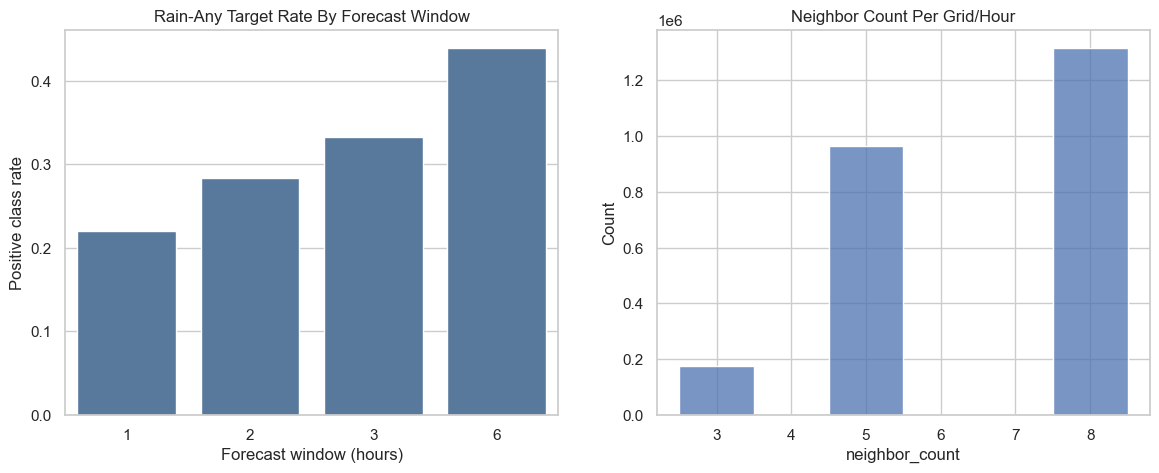

In [6]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": len(df),
        "rain_rows": int(df[f"rain_any_next_{horizon}h"].sum()),
        "rain_rate": float(df[f"rain_any_next_{horizon}h"].mean()),
    }
    for horizon in HORIZONS
])
display(target_balance)

neighbor_summary = df[NEIGHBOR_FEATURE_COLUMNS].describe().T
neighbor_summary["missing"] = df[NEIGHBOR_FEATURE_COLUMNS].isna().sum()
display(neighbor_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8", ax=axes[0])
axes[0].set_title("Rain-Any Target Rate By Forecast Window")
axes[0].set_xlabel("Forecast window (hours)")
axes[0].set_ylabel("Positive class rate")
sns.histplot(data=df, x="neighbor_count", discrete=True, ax=axes[1])
axes[1].set_title("Neighbor Count Per Grid/Hour")
plt.show()

## 6. Chronological Split

In [7]:
def add_time_split(data, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.array(sorted(data["forecast_time"].unique()))
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    out = data.copy()
    out["split"] = "test"
    out.loc[out["forecast_time"] < train_end, "split"] = "train"
    out.loc[(out["forecast_time"] >= train_end) & (out["forecast_time"] < validation_end), "split"] = "validation"
    return out, train_end, validation_end

model_df, train_end, validation_end = add_time_split(df, TRAIN_FRACTION, VALIDATION_FRACTION)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
display(model_df.groupby("split").size().rename("rows").reset_index())

train_df = model_df[model_df["split"] == "train"]
validation_df = model_df[model_df["split"] == "validation"]
test_df = model_df[model_df["split"] == "test"]

x_by_feature_set = {
    feature_set: {
        "train": train_df[columns].astype("float32"),
        "validation": validation_df[columns].astype("float32"),
        "test": test_df[columns].astype("float32"),
    }
    for feature_set, columns in FEATURE_SETS.items()
}

Train before: 2025-01-18 05:00:00
Validation before: 2025-10-19 01:00:00


,split,rows
0,test,367960
1,train,1717576
2,validation,368032


## 7. Evaluation Helpers

In [8]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, feature_set, horizon, split):
    base = {
        "model": model_name,
        "feature_set": feature_set,
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(
            ["model", "feature_set", "horizon_h", "split", "f1"],
            ascending=[True, True, True, True, False],
        )
        .groupby(["model", "feature_set", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "feature_set", "horizon_h", "split"])
    )


def compare_lift(metrics, baseline_feature_set="baseline", challenger_feature_set="neighbor_grid"):
    baseline = metrics[metrics["feature_set"] == baseline_feature_set]
    challenger = metrics[metrics["feature_set"] == challenger_feature_set]
    comparison = baseline.merge(
        challenger,
        on=["model", "horizon_h", "split"],
        suffixes=("_baseline", "_neighbor"),
    )
    for metric in ["roc_auc", "pr_auc", "brier_score"]:
        comparison[f"{metric}_delta"] = comparison[f"{metric}_neighbor"] - comparison[f"{metric}_baseline"]
    return comparison.sort_values(["model", "split", "horizon_h"])

## 8. Train HistGradientBoosting Baseline Vs Neighbor Models

In [9]:
hist_models = {}
hist_metric_rows = []
hist_threshold_tables = []

for feature_set, columns in FEATURE_SETS.items():
    for horizon in HORIZONS:
        target = f"rain_any_next_{horizon}h"
        print(f"Training HistGradientBoosting | {feature_set} | {target}...")
        y_train = train_df[target].astype("int8")
        y_validation = validation_df[target].astype("int8")
        y_test = test_df[target].astype("int8")

        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        )
        model.fit(x_by_feature_set[feature_set]["train"], y_train)
        hist_models[(feature_set, horizon)] = model

        for split_name, y_split in [("validation", y_validation), ("test", y_test)]:
            probabilities = model.predict_proba(x_by_feature_set[feature_set][split_name])[:, 1]
            metrics, thresholds = evaluate_probabilities(
                y_split.to_numpy(), probabilities, "hist_gradient_boosting", feature_set, horizon, split_name
            )
            hist_metric_rows.append(metrics)
            hist_threshold_tables.append(thresholds)

hist_metrics = pd.DataFrame(hist_metric_rows)
hist_threshold_results = pd.concat(hist_threshold_tables, ignore_index=True)
hist_lift = compare_lift(hist_metrics)

display(hist_metrics.sort_values(["feature_set", "horizon_h", "split"]))
display(hist_lift[hist_lift["split"] == "test"][[
    "model", "horizon_h", "split", "pr_auc_baseline", "pr_auc_neighbor", "pr_auc_delta",
    "roc_auc_baseline", "roc_auc_neighbor", "roc_auc_delta",
    "brier_score_baseline", "brier_score_neighbor", "brier_score_delta",
]])
display(best_thresholds(hist_threshold_results))

Training HistGradientBoosting | baseline | rain_any_next_1h...
Training HistGradientBoosting | baseline | rain_any_next_2h...
Training HistGradientBoosting | baseline | rain_any_next_3h...
Training HistGradientBoosting | baseline | rain_any_next_6h...
Training HistGradientBoosting | neighbor_grid | rain_any_next_1h...
Training HistGradientBoosting | neighbor_grid | rain_any_next_2h...
Training HistGradientBoosting | neighbor_grid | rain_any_next_3h...
Training HistGradientBoosting | neighbor_grid | rain_any_next_6h...


,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,hist_gradient_boosting,baseline,1,test,367960,0.1624,0.9162,0.7217,0.0770
0,hist_gradient_boosting,baseline,1,validation,368032,0.2687,0.8968,0.7805,0.1093
3,hist_gradient_boosting,baseline,2,test,367960,0.2184,0.8992,0.7380,0.1000
2,hist_gradient_boosting,baseline,2,validation,368032,0.3495,0.8811,0.8082,0.1315
5,hist_gradient_boosting,baseline,3,test,367960,0.2632,0.8929,0.7625,0.1134
4,hist_gradient_boosting,baseline,3,validation,368032,0.4111,0.8760,0.8337,0.1411
7,hist_gradient_boosting,baseline,6,test,367960,0.3644,0.8871,0.8183,0.1328
6,hist_gradient_boosting,baseline,6,validation,368032,0.5389,0.8737,0.8854,0.1451
9,hist_gradient_boosting,neighbor_grid,1,test,367960,0.1624,0.9317,0.7587,0.0706
8,hist_gradient_boosting,neighbor_grid,1,validation,368032,0.2687,0.9135,0.8113,0.1008


,model,horizon_h,split,pr_auc_baseline,pr_auc_neighbor,pr_auc_delta,roc_auc_baseline,roc_auc_neighbor,roc_auc_delta,brier_score_baseline,brier_score_neighbor,brier_score_delta
1,hist_gradient_boosting,1,test,0.7217,0.7587,0.0369,0.9162,0.9317,0.0155,0.0770,0.0706,-0.0063
3,hist_gradient_boosting,2,test,0.7380,0.7646,0.0266,0.8992,0.9114,0.0122,0.1000,0.0941,-0.0059
5,hist_gradient_boosting,3,test,0.7625,0.7815,0.0190,0.8929,0.9024,0.0096,0.1134,0.1085,-0.0049
7,hist_gradient_boosting,6,test,0.8183,0.8273,0.0090,0.8871,0.8924,0.0053,0.1328,0.1295,-0.0032


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
21,0.3000,0.1659,0.8898,0.6572,0.6713,0.6641,287290,20922,19642,40106,hist_gradient_boosting,baseline,1,test,367960,0.1624,0.9162,0.7217,0.0770
5,0.3500,0.2916,0.8404,0.6872,0.7457,0.7152,235564,33573,25151,73744,hist_gradient_boosting,baseline,1,validation,368032,0.2687,0.8968,0.7805,0.1093
54,0.2500,0.2612,0.8421,0.6158,0.7364,0.6707,250681,36924,21178,59177,hist_gradient_boosting,baseline,2,test,367960,0.2184,0.8992,0.7380,0.1000
39,0.3500,0.3864,0.8023,0.6965,0.7701,0.7314,196239,43170,29572,99051,hist_gradient_boosting,baseline,2,validation,368032,0.3495,0.8811,0.8082,0.1315
88,0.2500,0.3233,0.8203,0.6291,0.7728,0.6936,227006,44118,21997,74839,hist_gradient_boosting,baseline,3,test,367960,0.2632,0.8929,0.7625,0.1134
73,0.3500,0.4636,0.7860,0.7126,0.8035,0.7553,167691,49035,29735,121571,hist_gradient_boosting,baseline,3,validation,368032,0.4111,0.8760,0.8337,0.1411
123,0.3000,0.4242,0.7985,0.6920,0.8055,0.7445,185786,48076,26082,108016,hist_gradient_boosting,baseline,6,test,367960,0.3644,0.8871,0.8183,0.1328
107,0.3500,0.6310,0.7776,0.7508,0.8791,0.8099,111826,57876,23983,174347,hist_gradient_boosting,baseline,6,validation,368032,0.5389,0.8737,0.8854,0.1451
157,0.3000,0.1793,0.8952,0.6605,0.7293,0.6932,285820,22392,16176,43572,hist_gradient_boosting,neighbor_grid,1,test,367960,0.1624,0.9317,0.7587,0.0706
141,0.3500,0.3051,0.8472,0.6899,0.7833,0.7337,234327,34810,21434,77461,hist_gradient_boosting,neighbor_grid,1,validation,368032,0.2687,0.9135,0.8113,0.1008


## 9. Train LightGBM Baseline Vs Neighbor Models

In [10]:
lgbm_models = {}
lgbm_metric_rows = []
lgbm_threshold_tables = []

if RUN_LIGHTGBM:
    try:
        from lightgbm import LGBMClassifier
    except ModuleNotFoundError:
        RUN_LIGHTGBM = False
        print("LightGBM is not installed. Skipping LightGBM comparison.")

if RUN_LIGHTGBM:
    for feature_set, columns in FEATURE_SETS.items():
        for horizon in HORIZONS:
            target = f"rain_any_next_{horizon}h"
            print(f"Training LightGBM | {feature_set} | {target}...")
            y_train = train_df[target].astype("int8")
            y_validation = validation_df[target].astype("int8")
            y_test = test_df[target].astype("int8")
            scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))

            model = LGBMClassifier(
                objective="binary",
                n_estimators=500,
                learning_rate=0.04,
                num_leaves=63,
                min_child_samples=80,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=1.0,
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
            model.fit(
                x_by_feature_set[feature_set]["train"],
                y_train,
                eval_set=[(x_by_feature_set[feature_set]["validation"], y_validation)],
                eval_metric="binary_logloss",
            )
            lgbm_models[(feature_set, horizon)] = model

            for split_name, y_split in [("validation", y_validation), ("test", y_test)]:
                probabilities = model.predict_proba(x_by_feature_set[feature_set][split_name])[:, 1]
                metrics, thresholds = evaluate_probabilities(
                    y_split.to_numpy(), probabilities, "lightgbm", feature_set, horizon, split_name
                )
                lgbm_metric_rows.append(metrics)
                lgbm_threshold_tables.append(thresholds)

if lgbm_metric_rows:
    lgbm_metrics = pd.DataFrame(lgbm_metric_rows)
    lgbm_threshold_results = pd.concat(lgbm_threshold_tables, ignore_index=True)
    lgbm_lift = compare_lift(lgbm_metrics)
    display(lgbm_metrics.sort_values(["feature_set", "horizon_h", "split"]))
    display(lgbm_lift[lgbm_lift["split"] == "test"][[
        "model", "horizon_h", "split", "pr_auc_baseline", "pr_auc_neighbor", "pr_auc_delta",
        "roc_auc_baseline", "roc_auc_neighbor", "roc_auc_delta",
        "brier_score_baseline", "brier_score_neighbor", "brier_score_delta",
    ]])
    display(best_thresholds(lgbm_threshold_results))
else:
    lgbm_metrics = pd.DataFrame()
    lgbm_threshold_results = pd.DataFrame()

Training LightGBM | baseline | rain_any_next_1h...
[LightGBM] [Info] Number of positive: 382511, number of negative: 1335065
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.168027 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[LightGBM] [Info] Number of data points in the train set: 1717576, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.222704 -> initscore=-1.249978
[LightGBM] [Info] Start training from score -1.249978
Training LightGBM | baseline | rain_any_next_2h...
[LightGBM] [Info] Number of positive: 487195, number of negative: 1230381
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.170368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4949
[

,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,baseline,1,test,367960,0.1624,0.9170,0.7223,0.0876
0,lightgbm,baseline,1,validation,368032,0.2687,0.8980,0.7819,0.1349
3,lightgbm,baseline,2,test,367960,0.2184,0.8997,0.7399,0.1052
2,lightgbm,baseline,2,validation,368032,0.3495,0.8822,0.8099,0.1456
5,lightgbm,baseline,3,test,367960,0.2632,0.8931,0.7623,0.1152
4,lightgbm,baseline,3,validation,368032,0.4111,0.8772,0.8354,0.1478
7,lightgbm,baseline,6,test,367960,0.3644,0.8868,0.8178,0.1314
6,lightgbm,baseline,6,validation,368032,0.5389,0.8756,0.8871,0.1435
9,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9330,0.7599,0.0819
8,lightgbm,neighbor_grid,1,validation,368032,0.2687,0.9148,0.8131,0.1256


,model,horizon_h,split,pr_auc_baseline,pr_auc_neighbor,pr_auc_delta,roc_auc_baseline,roc_auc_neighbor,roc_auc_delta,brier_score_baseline,brier_score_neighbor,brier_score_delta
1,lightgbm,1,test,0.7223,0.7599,0.0376,0.9170,0.9330,0.0160,0.0876,0.0819,-0.0057
3,lightgbm,2,test,0.7399,0.7669,0.0270,0.8997,0.9123,0.0127,0.1052,0.0993,-0.0059
5,lightgbm,3,test,0.7623,0.7812,0.0189,0.8931,0.9024,0.0093,0.1152,0.1105,-0.0047
7,lightgbm,6,test,0.8178,0.8260,0.0083,0.8868,0.8917,0.0049,0.1314,0.1285,-0.0029


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
26,0.5500,0.1780,0.8853,0.6339,0.6950,0.6630,284227,23985,18224,41524,lightgbm,baseline,1,test,367960,0.1624,0.9170,0.7223,0.0876
11,0.6500,0.2901,0.8417,0.6903,0.7451,0.7167,236075,33062,25207,73688,lightgbm,baseline,1,validation,368032,0.2687,0.8980,0.7819,0.1349
58,0.4500,0.2616,0.8419,0.6152,0.7369,0.6706,250560,37045,21138,59217,lightgbm,baseline,2,test,367960,0.2184,0.8997,0.7399,0.1052
43,0.5500,0.4001,0.7994,0.6860,0.7854,0.7324,193180,46229,27606,101017,lightgbm,baseline,2,validation,368032,0.3495,0.8822,0.8099,0.1456
91,0.4000,0.3227,0.8204,0.6295,0.7719,0.6935,227140,43984,22093,74743,lightgbm,baseline,3,test,367960,0.2632,0.8931,0.7623,0.1152
76,0.5000,0.4768,0.7839,0.7045,0.8171,0.7567,164872,51854,27668,123638,lightgbm,baseline,3,validation,368032,0.4111,0.8772,0.8354,0.1478
124,0.3500,0.4308,0.7969,0.6873,0.8124,0.7446,184295,49567,25160,108938,lightgbm,baseline,6,test,367960,0.3644,0.8868,0.8178,0.1314
108,0.4000,0.6397,0.7783,0.7479,0.8879,0.8119,110357,59345,22240,176090,lightgbm,baseline,6,validation,368032,0.5389,0.8756,0.8871,0.1435
163,0.6000,0.1760,0.8967,0.6679,0.7241,0.6949,286701,21511,16484,43264,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9330,0.7599,0.0819
147,0.6500,0.3030,0.8494,0.6949,0.7836,0.7366,235117,34020,21402,77493,lightgbm,neighbor_grid,1,validation,368032,0.2687,0.9148,0.8131,0.1256


## 10. Compare All Results

,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,hist_gradient_boosting,baseline,1,test,367960,0.1624,0.9162,0.7217,0.0770
0,hist_gradient_boosting,baseline,1,validation,368032,0.2687,0.8968,0.7805,0.1093
3,hist_gradient_boosting,baseline,2,test,367960,0.2184,0.8992,0.7380,0.1000
2,hist_gradient_boosting,baseline,2,validation,368032,0.3495,0.8811,0.8082,0.1315
5,hist_gradient_boosting,baseline,3,test,367960,0.2632,0.8929,0.7625,0.1134
4,hist_gradient_boosting,baseline,3,validation,368032,0.4111,0.8760,0.8337,0.1411
7,hist_gradient_boosting,baseline,6,test,367960,0.3644,0.8871,0.8183,0.1328
6,hist_gradient_boosting,baseline,6,validation,368032,0.5389,0.8737,0.8854,0.1451
9,hist_gradient_boosting,neighbor_grid,1,test,367960,0.1624,0.9317,0.7587,0.0706
8,hist_gradient_boosting,neighbor_grid,1,validation,368032,0.2687,0.9135,0.8113,0.1008


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
21,0.3000,0.1659,0.8898,0.6572,0.6713,0.6641,287290,20922,19642,40106,hist_gradient_boosting,baseline,1,test,367960,0.1624,0.9162,0.7217,0.0770
157,0.3000,0.1793,0.8952,0.6605,0.7293,0.6932,285820,22392,16176,43572,hist_gradient_boosting,neighbor_grid,1,test,367960,0.1624,0.9317,0.7587,0.0706
298,0.5500,0.1780,0.8853,0.6339,0.6950,0.6630,284227,23985,18224,41524,lightgbm,baseline,1,test,367960,0.1624,0.9170,0.7223,0.0876
435,0.6000,0.1760,0.8967,0.6679,0.7241,0.6949,286701,21511,16484,43264,lightgbm,neighbor_grid,1,test,367960,0.1624,0.9330,0.7599,0.0819
54,0.2500,0.2612,0.8421,0.6158,0.7364,0.6707,250681,36924,21178,59177,hist_gradient_boosting,baseline,2,test,367960,0.2184,0.8992,0.7380,0.1000
191,0.3000,0.2430,0.8581,0.6573,0.7314,0.6924,256962,30643,21583,58772,hist_gradient_boosting,neighbor_grid,2,test,367960,0.2184,0.9114,0.7646,0.0941
330,0.4500,0.2616,0.8419,0.6152,0.7369,0.6706,250560,37045,21138,59217,lightgbm,baseline,2,test,367960,0.2184,0.8997,0.7399,0.1052
467,0.5000,0.2480,0.8572,0.6524,0.7407,0.6937,255887,31718,20834,59521,lightgbm,neighbor_grid,2,test,367960,0.2184,0.9123,0.7669,0.0993
88,0.2500,0.3233,0.8203,0.6291,0.7728,0.6936,227006,44118,21997,74839,hist_gradient_boosting,baseline,3,test,367960,0.2632,0.8929,0.7625,0.1134
225,0.3000,0.2960,0.8365,0.6683,0.7518,0.7076,234988,36136,24039,72797,hist_gradient_boosting,neighbor_grid,3,test,367960,0.2632,0.9024,0.7815,0.1085


,model,horizon_h,split,pr_auc_baseline,pr_auc_neighbor,pr_auc_delta,roc_auc_baseline,roc_auc_neighbor,roc_auc_delta,brier_score_baseline,brier_score_neighbor,brier_score_delta
1,hist_gradient_boosting,1,test,0.7217,0.7587,0.0369,0.9162,0.9317,0.0155,0.0770,0.0706,-0.0063
9,lightgbm,1,test,0.7223,0.7599,0.0376,0.9170,0.9330,0.0160,0.0876,0.0819,-0.0057
3,hist_gradient_boosting,2,test,0.7380,0.7646,0.0266,0.8992,0.9114,0.0122,0.1000,0.0941,-0.0059
11,lightgbm,2,test,0.7399,0.7669,0.0270,0.8997,0.9123,0.0127,0.1052,0.0993,-0.0059
5,hist_gradient_boosting,3,test,0.7625,0.7815,0.0190,0.8929,0.9024,0.0096,0.1134,0.1085,-0.0049
13,lightgbm,3,test,0.7623,0.7812,0.0189,0.8931,0.9024,0.0093,0.1152,0.1105,-0.0047
7,hist_gradient_boosting,6,test,0.8183,0.8273,0.0090,0.8871,0.8924,0.0053,0.1328,0.1295,-0.0032
15,lightgbm,6,test,0.8178,0.8260,0.0083,0.8868,0.8917,0.0049,0.1314,0.1285,-0.0029


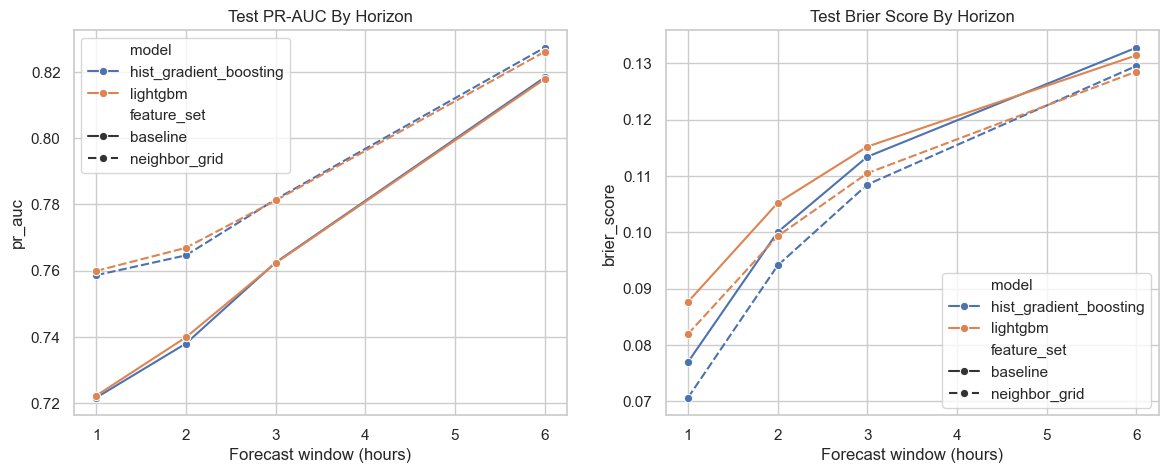

In [11]:
all_metrics = pd.concat([hist_metrics, lgbm_metrics], ignore_index=True)
all_threshold_results = pd.concat([hist_threshold_results, lgbm_threshold_results], ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)
lift = compare_lift(all_metrics)

display(all_metrics.sort_values(["model", "feature_set", "horizon_h", "split"]))
display(best_by_f1[best_by_f1["split"] == "test"].sort_values(["horizon_h", "model", "feature_set"]))
display(lift[lift["split"] == "test"][[
    "model", "horizon_h", "split", "pr_auc_baseline", "pr_auc_neighbor", "pr_auc_delta",
    "roc_auc_baseline", "roc_auc_neighbor", "roc_auc_delta",
    "brier_score_baseline", "brier_score_neighbor", "brier_score_delta",
]].sort_values(["horizon_h", "model"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="pr_auc", hue="model", style="feature_set", marker="o", ax=axes[0])
axes[0].set_title("Test PR-AUC By Horizon")
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="brier_score", hue="model", style="feature_set", marker="o", ax=axes[1])
axes[1].set_title("Test Brier Score By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast window (hours)")
plt.show()

## 11. Neighbor Feature Importance

,model,feature_set,horizon_h,feature,importance,is_neighbor_feature
11,lightgbm,neighbor_grid,1,pressure_msl_change_6h,1578.0000,False
8,lightgbm,neighbor_grid,1,wind_direction_10m,1571.0000,False
10,lightgbm,neighbor_grid,1,pressure_msl_change_3h,1481.0000,False
29,lightgbm,neighbor_grid,1,hour_cos,1325.0000,False
50,lightgbm,neighbor_grid,1,neighbor_dew_point_2m_mean,1209.0000,True
...,...,...,...,...,...,...
216,lightgbm,neighbor_grid,6,precipitation_sum_past_12h,632.0000,False
251,lightgbm,neighbor_grid,6,neighbor_wind_speed_10m_max,592.0000,True
220,lightgbm,neighbor_grid,6,cloud_cover_lag_6h,558.0000,False
222,lightgbm,neighbor_grid,6,humidity_lag_3h,553.0000,False


,model,feature_set,horizon_h,feature,importance,is_neighbor_feature
50,lightgbm,neighbor_grid,1,neighbor_dew_point_2m_mean,1209.0000,True
49,lightgbm,neighbor_grid,1,neighbor_temperature_2m_mean,933.0000,True
47,lightgbm,neighbor_grid,1,neighbor_pressure_msl_min,909.0000,True
46,lightgbm,neighbor_grid,1,neighbor_pressure_msl_mean,862.0000,True
53,lightgbm,neighbor_grid,1,neighbor_wind_speed_10m_max,796.0000,True
48,lightgbm,neighbor_grid,1,neighbor_pressure_msl_max,772.0000,True
45,lightgbm,neighbor_grid,1,neighbor_relative_humidity_max,551.0000,True
37,lightgbm,neighbor_grid,1,neighbor_precipitation_mean,521.0000,True
52,lightgbm,neighbor_grid,1,neighbor_wind_speed_10m_mean,506.0000,True
65,lightgbm,neighbor_grid,1,center_pressure_msl_minus_neighbor_mean,448.0000,True


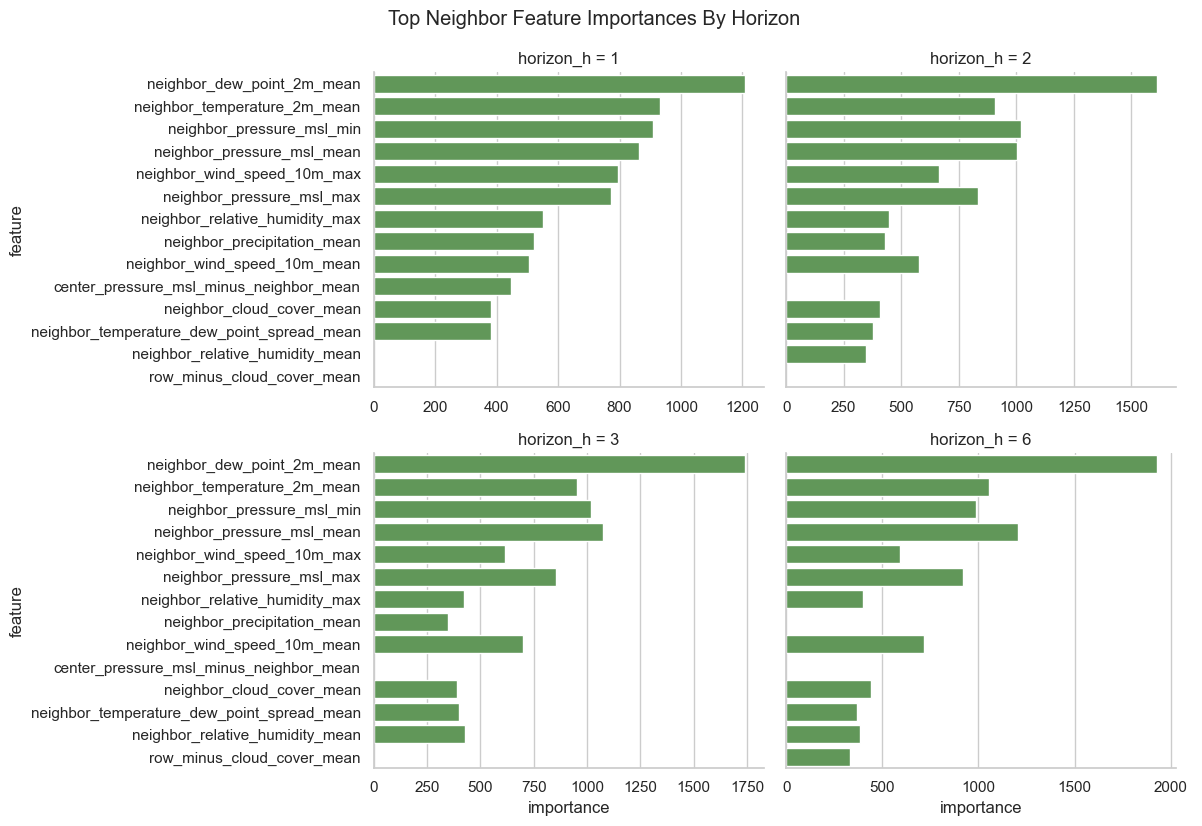

In [12]:
if lgbm_models:
    importance_rows = []
    for (feature_set, horizon), model in lgbm_models.items():
        if feature_set != "neighbor_grid":
            continue
        for feature, importance in zip(FEATURE_SETS[feature_set], model.feature_importances_):
            importance_rows.append({
                "model": "lightgbm",
                "feature_set": feature_set,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })
    feature_importance = pd.DataFrame(importance_rows)
    display(feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False]).groupby("horizon_h").head(20))

    top_neighbor_importance = (
        feature_importance[feature_importance["is_neighbor_feature"]]
        .sort_values(["horizon_h", "importance"], ascending=[True, False])
        .groupby("horizon_h")
        .head(12)
    )
    display(top_neighbor_importance)

    g = sns.catplot(
        data=top_neighbor_importance,
        x="importance",
        y="feature",
        col="horizon_h",
        kind="bar",
        col_wrap=2,
        sharex=False,
        height=4,
        aspect=1.5,
        color="#59a14f",
    )
    g.fig.suptitle("Top Neighbor Feature Importances By Horizon", y=1.03)
    plt.show()
else:
    feature_importance = pd.DataFrame()
    print("LightGBM models are unavailable, so feature importance is skipped.")

## 12. Save Experiment Artifacts

In [13]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for (feature_set, horizon), model in hist_models.items():
    path = MODEL_DIR / f"om_bkk_rain_any_next_{horizon}h_{feature_set}_histgbm_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    joblib.dump(model, path)

for (feature_set, horizon), model in lgbm_models.items():
    path = MODEL_DIR / f"om_bkk_rain_any_next_{horizon}h_{feature_set}_lightgbm_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "rain_any_neighbor_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "rain_any_neighbor_multi_horizon_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "rain_any_neighbor_multi_horizon_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "rain_any_neighbor_multi_horizon_best_thresholds_by_f1.csv", index=False)
lift.to_csv(MODEL_DIR / "rain_any_neighbor_lift_vs_baseline.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "rain_any_neighbor_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "target_type": "rain_any_within_next_n_hours",
    "experiment": "baseline_vs_neighbor_grid_features",
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_sets": FEATURE_SETS,
    "neighbor_feature_description": "Aggregates from adjacent grid cells within +/-1 grid_row and +/-1 grid_column at the same forecast timestamp, excluding the center grid cell.",
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
    "lift_vs_baseline": lift.to_dict(orient="records"),
}
(MODEL_DIR / "rain_any_neighbor_multi_horizon_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved neighbor-grid experiment models and result CSVs to {MODEL_DIR}")

Saved neighbor-grid experiment models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\om_bkk_rain_any_neighbor_grid_experiment
